In [2]:
"""
INTEGRATED FIGURE 1: Complete Analysis Pipeline
Fixed version with proper execution order
"""

# %%
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import warnings
from scipy.sparse import csr_matrix
from scipy import stats
from datetime import datetime
from tqdm import tqdm
from scipy import stats
from scipy.sparse import issparse
import sys 

warnings.filterwarnings("ignore")

# Import ATSE coordination functions
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation') 

# Plotting configuration
sns.set_theme(context="notebook", style="white")
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.grid': False,
})

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

from atse_viz import *
import gffutils

gtf_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/2025_mouse_longread/2025_mouse_collapse_GRCm38/all_samples_sp_collapse_all_chr_full.gtf"
db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/genomes/lr_GRCm38.db"

# Load the database
db_mouse = gffutils.FeatureDB(db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [3]:
# Setup
today = datetime.now().strftime("%Y%m%d")
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"

# =========================================================================
# PART 1: Load and Preprocess Data
# =========================================================================

print("\n" + "="*60)
print("PART 1: DATA LOADING AND PREPROCESSING")
print("="*60)

ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-10-01_21-36-40.txt.gz"
full_atse_map = pd.read_csv(ATSE_FILE_PATH, sep="\t")

print("Loading data...")

output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs"
# make output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# load all ATSEs for coordination analysis 
all_juncs = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/junction_df_all_20251020.csv"
all_atses = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/atse_df_all_20251020.csv"
all_juncs_df = pd.read_csv(all_juncs)
all_atses_df = pd.read_csv(all_atses)
all_juncs_df.head()
all_atses_df.head()


PART 1: DATA LOADING AND PREPROCESSING
Loading data...


,cell_type,event_id,n_junctions,mean_delta_mean,median_delta_median,mean_abs_delta,std_delta,sign_concordance,mean_delta_pb,median_delta_pb,opposite_sign_pair
0,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019966.18_atse_1,2,-1.387779e-17,0.000000,0.004092,0.005787,0.500000,1.040834e-17,1.040834e-17,1.0
1,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019966.18_atse_2,3,2.775558e-17,-0.006706,0.022149,0.029925,0.666667,9.251859e-18,1.517588e-02,NaN
2,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000036676.14_atse_2,2,-2.775558e-17,0.000000,0.142857,0.202031,0.500000,-1.387779e-17,-1.387779e-17,1.0
3,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000036676.14_atse_1,4,0.000000e+00,0.000000,0.107143,0.163684,0.750000,-2.775558e-17,7.836134e-02,NaN
4,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019971.10_atse_1,3,9.251859e-18,0.000000,0.047619,0.071429,0.500000,-1.850372e-17,0.000000e+00,NaN


In [4]:
# found whcih event_id corresponds to "chr5_8046215_8057537_+" junction 
full_atse_map[full_atse_map["junction_id"] == "chr10_39526930_39529436_+"]["event_id"]

33959    ENSMUSG00000019843.14_atse_3
Name: event_id, dtype: object

Unique transcripts: {'ENSMUST00000126486.7', 's4e573aa6bf6a147c:ea6ce8b3fbcb59d4a', 's4e573aa6bf6a147c:e59320f24dcc6bb9a', 's9afe5da69361b8dc:ed1bdfa713fba8e19', 'sbe04fc015d33f74a:e7f4d92c17c25b0a9', 'ENSMUST00000063091.12', 's77df342ce74e2de2:e1f150e1c3abd4796', 'sb36c5857c401cc8b:ebcf913e3f4e6bbbf', 'ENSMUST00000099967.9', 'sa748d181a4b8016c:e01f2666678336523', 's97d0e8ce56ba1ebb:e410c469e63ecf9b8', 's210bb405a66baa07:ecde3793890fad002', 'sb36c5857c401cc8b:ee6aefe0d8d24f055', 's37b61395f1bad2bc:e6f24d61125fb33d3', 'sb36c5857c401cc8b:ece08b98c7aa0560c', 's1a66fcdcdc4f5ce1:ecde3793890fad002', 's0ee8e588831dbdb2:efbbab4d1a73da1d5', 's2934ab59ebeccd68:ecde3793890fad002', 'sa46b64f38667f79c:effbe81ef27d98698', 's6c851e4c38c67596:eacca81c0f7047828', 's97d0e8ce56ba1ebb:e0ba98455ef3c0090', 's35ece05f30c1b16a:e675f05cda36a2f65'}
Unique transcripts: ['ENSMUST00000063091.12', 'ENSMUST00000099967.9', 'ENSMUST00000126486.7']
Unique transcripts to remove: ['s0ee8e588831dbdb2:efbbab4d1a73da1d5', '

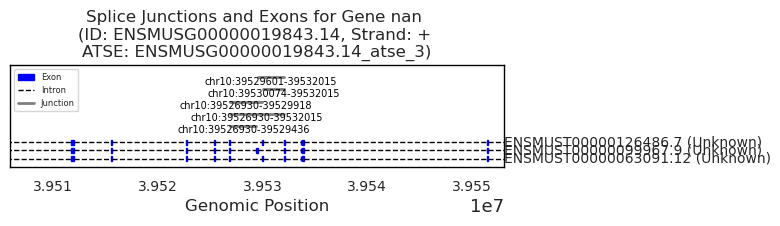

ATSE visualization saved: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/ATSE_plotter/101143_mouse_nan_ENSMUSG00000019843.14_atse_3.pdf


{'junctions':                            event_id                gene_id  gene_name  \
 33959  ENSMUSG00000019843.14_atse_3  ENSMUSG00000019843.14        NaN   
 33960  ENSMUSG00000019843.14_atse_3  ENSMUSG00000019843.14        NaN   
 33961  ENSMUSG00000019843.14_atse_3  ENSMUSG00000019843.14        NaN   
 33962  ENSMUSG00000019843.14_atse_3  ENSMUSG00000019843.14        NaN   
 33963  ENSMUSG00000019843.14_atse_3  ENSMUSG00000019843.14        NaN   
 
        gene_types  num_junctions event_type chromosome strand  atse_start  \
 33959         NaN              5    complex      chr10      +    39526930   
 33960         NaN              5    complex      chr10      +    39526930   
 33961         NaN              5    complex      chr10      +    39526930   
 33962         NaN              5    complex      chr10      +    39526930   
 33963         NaN              5    complex      chr10      +    39526930   
 
        atse_end  ...  acceptor_usage  donor_total_reads  acceptor_tota

In [5]:
mouse_event = "ENSMUSG00000019843.14_atse_3"
visualize_atse_event(mouse_event, full_atse_map, db_mouse,
                 species="mouse", base_width=8, 
                       trans_height=0.4, output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/ATSE_plotter",
                  padding=20000, show_junc_lines=False, filter_ensembl_transcripts=True)